In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12,5)
sns.set_style("whitegrid")

In [2]:
oil = pd.read_csv("brent_crude.csv")
events = pd.read_csv("geopolitical_events.csv")

In [3]:
oil.head()

,date,brent_price
0,2010-01-04,80.120003
1,2010-01-05,80.589996
2,2010-01-06,81.889999
3,2010-01-07,81.510002
4,2010-01-08,81.370003


In [4]:
print("Oil Dataset Columns:")
print(oil.columns)

print("\nEvents Dataset Columns:")
print(events.columns)

Oil Dataset Columns:
Index(['date', 'brent_price'], dtype='object')

Events Dataset Columns:
Index(['event_date', 'event_name', 'severity'], dtype='object')


In [5]:
oil.isnull().sum()

date           0
brent_price    0
dtype: int64

In [6]:
events.isnull().sum()

event_date    0
event_name    0
severity      0
dtype: int64

In [7]:
oil['date'] = pd.to_datetime(oil['date'])
events['event_date'] = pd.to_datetime(events['event_date'])

In [8]:
df = pd.merge(
    oil,
    events,
    left_on="date",
    right_on="event_date",
    how="left"
)

df.head()

,date,brent_price,event_date,event_name,severity
0,2010-01-04,80.120003,NaT,NaN,NaN
1,2010-01-05,80.589996,NaT,NaN,NaN
2,2010-01-06,81.889999,NaT,NaN,NaN
3,2010-01-07,81.510002,NaT,NaN,NaN
4,2010-01-08,81.370003,NaT,NaN,NaN


In [22]:
df.drop("event_date", axis=1, inplace=True)

In [23]:
df["event_name"] = df["event_name"].fillna("No Event")
df["severity"] = df["severity"].fillna(0)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4049 entries, 0 to 4048
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         4049 non-null   datetime64[ns]
 1   brent_price  4049 non-null   float64       
 2   event_name   4049 non-null   object        
 3   severity     4049 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 126.7+ KB


In [25]:
df.describe()

,date,brent_price
count,4049,4049.000000
mean,2018-02-27 10:31:37.357372160,77.444967
min,2010-01-04 00:00:00,19.330000
25%,2014-02-27 00:00:00,60.849998
50%,2018-03-08 00:00:00,75.080002
75%,2022-03-15 00:00:00,97.339996
max,2026-03-24 00:00:00,127.980003
std,NaN,23.360104


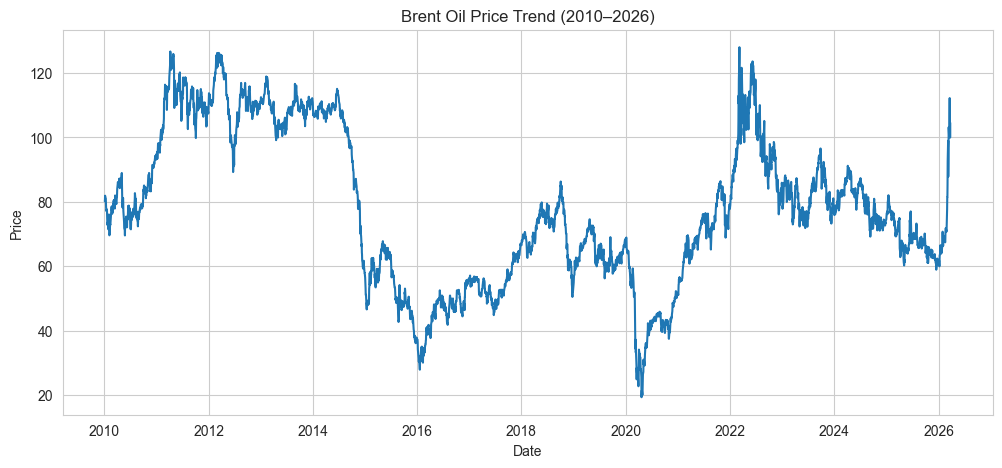

In [26]:
plt.plot(df["date"], df["brent_price"])

plt.title("Brent Oil Price Trend (2010–2026)")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

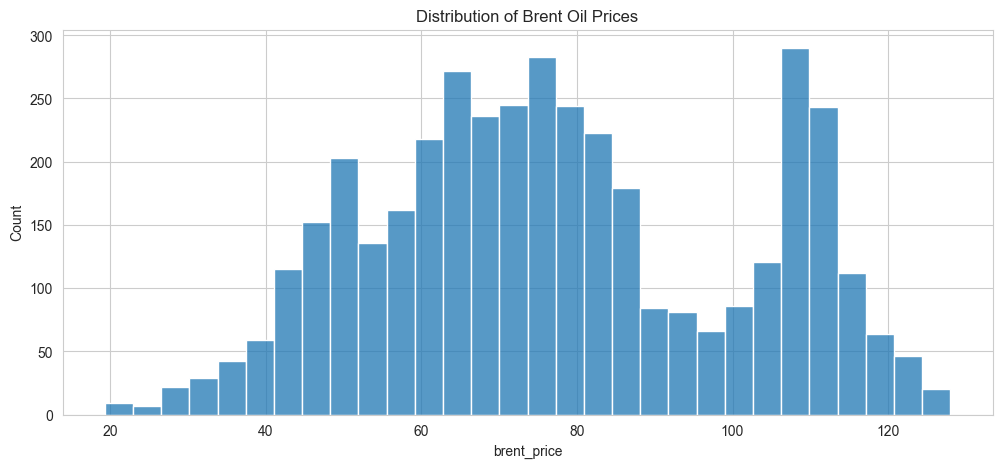

In [27]:
sns.histplot(df["brent_price"], bins=30)

plt.title("Distribution of Brent Oil Prices")

plt.show()

In [28]:
df["event_flag"] = df["event_name"].apply(lambda x: 0 if x=="No Event" else 1)

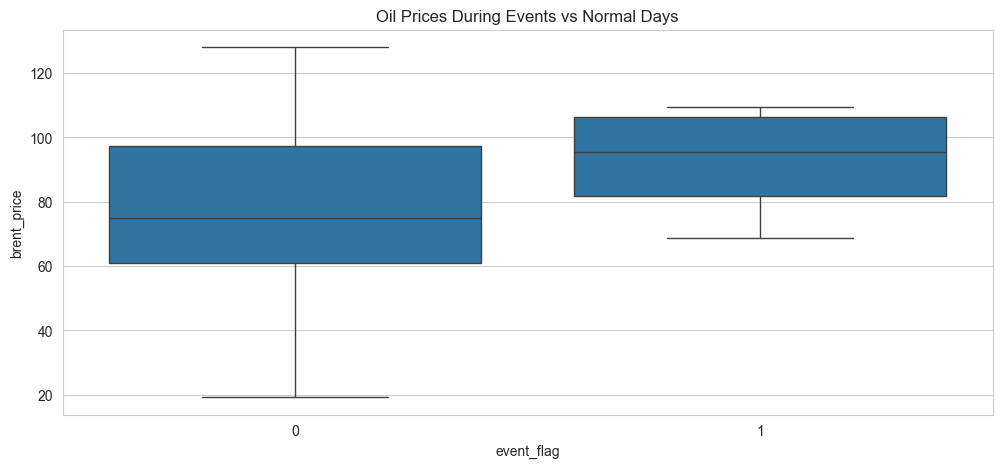

In [29]:
sns.boxplot(x="event_flag", y="brent_price", data=df)

plt.title("Oil Prices During Events vs Normal Days")

plt.show()

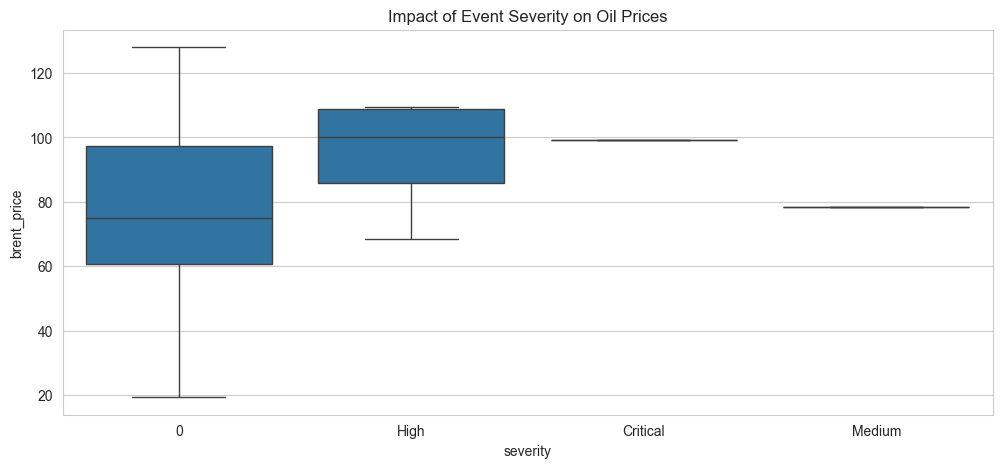

In [30]:
sns.boxplot(x="severity", y="brent_price", data=df)

plt.title("Impact of Event Severity on Oil Prices")

plt.show()

In [31]:
df.groupby("event_name")["brent_price"].mean().sort_values(ascending=False).head(10)

event_name
ISIS Iraq Offensive        109.519997
Libya Civil War            108.519997
Russia-Ukraine War          99.080002
Arab Spring                 91.669998
Red Sea Attacks             78.290001
No Event                    77.422456
Soleimani Assassination     68.599998
Name: brent_price, dtype: float64

In [9]:
df[["date","brent_price"]].sort_values(by="brent_price", ascending=False).head(10)

,date,brent_price
3031,2022-03-08,127.980003
315,2011-04-08,126.650002
538,2012-03-13,126.220001
530,2012-03-01,126.199997
536,2012-03-09,125.980003
328,2011-04-29,125.889999
541,2012-03-16,125.809998
542,2012-03-19,125.709999
547,2012-03-26,125.650002
548,2012-03-27,125.540001


In [10]:
df.to_csv("oil_analysis_clean.csv", index=False)

In [12]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",                # your MySQL username
    password="Rakshitha@03",    # your MySQL password
    database="geopolitical_db"     # your database name in workbench
)

print("Connected Successfully!")

Connected Successfully!
